In [3]:
!conda install -c psi4 psi4 -c conda-forge -y
!pip install rdkit pandas numpy matplotlib py3Dmol jupyter

/bin/bash: line 1: conda: command not found
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 128.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 102.0 MB/s eta 0:00:00


In [ ]:
import os

folders = [
    'phase4_member1/inputs/candidates_3d',
    'phase4_member1/psi4_runs',
    'phase4_member1/outputs/qm/esp_maps',
    'phase4_member1/notebooks'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f" Created: {folder}")

print("\n Folder structure ready!")

 Created: phase4_member1/inputs/candidates_3d
 Created: phase4_member1/psi4_runs
 Created: phase4_member1/outputs/qm/esp_maps
 Created: phase4_member1/notebooks

 Folder structure ready!


In [ ]:
for root, dirs, files in os.walk('phase4_member1'):
    level = root.replace('phase4_member1', '').count(os.sep)
    indent = '│   ' * level + '├── '
    print(f"{indent}{os.path.basename(root)}/")

├── phase4_member1/
│   ├── inputs/
│   │   ├── candidates_3d/
│   ├── psi4_runs/
│   ├── notebooks/
│   ├── outputs/
│   │   ├── qm/
│   │   │   ├── esp_maps/


In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [ ]:
import os

base_path = '/content/drive/MyDrive/phase4_member1'

folders = [
    f'{base_path}/inputs/candidates_3d',
    f'{base_path}/psi4_runs',
    f'{base_path}/outputs/qm/esp_maps',
    f'{base_path}/notebooks'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f" Created: {folder}")

print("\n All folders saved to Google Drive!")

 Created: /content/drive/MyDrive/phase4_member1/inputs/candidates_3d
 Created: /content/drive/MyDrive/phase4_member1/psi4_runs
 Created: /content/drive/MyDrive/phase4_member1/outputs/qm/esp_maps
 Created: /content/drive/MyDrive/phase4_member1/notebooks

 All folders saved to Google Drive!


In [4]:
!pip install condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:10
🔁 Restarting kernel...


In [1]:
!conda install -c psi4 psi4 -c conda-forge -y

Channels:
 - psi4
 - conda-forge
Platform: linux-64
Solving environment: - \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - psi4


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |       7_kmp_llvm           8 KB  conda-forge
    annotated-types-0.7.0      |     pyhd8ed1ab_1          18 KB  conda-forge
    armadillo-14.6.3           |       h7dbe251_0         541 KB  conda-forge
    arpack-3.9.1               |nompi_hf03ea27_102         127 KB  conda-forge
    c-ares-1.34.6              |       hb03c661_0         203 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    conda-26.1.1               |  py311h38be061_0         1.2 MB  conda-forge
    conda-libmamba-solver-25.11.0|     pyh

In [3]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/phase4_member1'
print("Drive mounted ")

Mounted at /content/drive
Drive mounted 


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import os

# Check if SDF files are already there
sdf_folder = f'{base_path}/inputs/candidates_3d'
files = os.listdir(sdf_folder)
print(f"SDF files found: {len(files)}")
for f in files:
    print(f"  - {f}")

SDF files found: 1
  - final_candidates_3d.sdf


In [4]:
import sys
sys.path.append('/usr/local/lib/python3.11/site-packages')

from rdkit import Chem
print("RDKit loaded ✅")

RDKit loaded ✅


In [13]:
import os
from rdkit import Chem

base_path = '/content/drive/MyDrive/phase4_member1'
sdf_folder = f'{base_path}/inputs/candidates_3d'

for filename in os.listdir(sdf_folder):
    if filename.endswith('.sdf'):
        mol = Chem.MolFromMolFile(f'{sdf_folder}/{filename}', removeHs=False)
        if mol:
            print(f"✅ {filename} — {mol.GetNumAtoms()} atoms")
        else:
            print(f"❌ {filename} — failed to read")

✅ final_candidates_3d.sdf — 40 atoms


In [14]:
from rdkit import Chem

def sdf_to_xyz(sdf_path):
    mol = Chem.MolFromMolFile(sdf_path, removeHs=False)
    if mol is None:
        raise ValueError(f"Could not read {sdf_path}")
    conf = mol.GetConformer()
    lines = ["0 1"]  # charge=0, multiplicity=1
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        lines.append(f"  {atom.GetSymbol()}  {pos.x:.6f}  {pos.y:.6f}  {pos.z:.6f}")
    return "\n".join(lines)

print("Converter ready ")

Converter ready 


In [15]:
import os

base_path = '/content/drive/MyDrive/phase4_member1'
sdf_folder = f'{base_path}/inputs/candidates_3d'

# Pick first SDF file to test
first_sdf = [f for f in os.listdir(sdf_folder) if f.endswith('.sdf')][0]
test_path  = f'{sdf_folder}/{first_sdf}'

xyz = sdf_to_xyz(test_path)
print(f"Testing on: {first_sdf}")
print("XYZ output preview:")
print(xyz[:300])
print(" Converter working!")

Testing on: final_candidates_3d.sdf
XYZ output preview:
0 1
  C  -0.075000  -2.071000  0.412600
  N  -0.763800  -0.786500  0.484500
  C  -0.169800  0.426300  0.126000
  O  -0.797100  1.448500  -0.138000
  C  1.308200  0.523300  0.083500
  C  1.915600  1.081000  -1.048500
  C  3.303700  1.223400  -1.095700
  C  4.074000  0.811100  -0.003100
  S  5.837900 
 Converter working!


In [7]:
!pip install pyscf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 MB 19.7 MB/s eta 0:00:00


In [8]:
from pyscf import gto, scf, dft
print("PySCF loaded ✅")

PySCF loaded ✅


In [21]:
def run_dft_fast(mol_name, sdf_path):
    print(f"\n🔬 Running {mol_name}...")

    atom_str = sdf_to_pyscf_atoms(sdf_path)

    mol = gto.Mole()
    mol.atom    = atom_str
    mol.basis   = 'sto-3g'   # lighter basis — much faster
    mol.charge  = 0
    mol.spin    = 0
    mol.verbose = 0
    mol.build()

    # Single point energy (skip optimization — saves huge time)
    mf = dft.RKS(mol)
    mf.xc     = 'B3LYP'
    mf.max_cycle = 100
    energy    = mf.kernel()

    mo_energies = mf.mo_energy * 27.2114
    n_occ       = mol.nelectron // 2
    homo        = mo_energies[n_occ - 1]
    lumo        = mo_energies[n_occ]
    gap         = lumo - homo

    charges = mf.mulliken_pop()[1]

    print(f"   Energy : {energy:.6f} Hartree")
    print(f"   HOMO   : {homo:.4f} eV")
    print(f"   LUMO   : {lumo:.4f} eV")
    print(f"   Gap    : {gap:.4f} eV")

    return {
        'mol_name'       : mol_name,
        'energy_hartree' : energy,
        'homo_ev'        : homo,
        'lumo_ev'        : lumo,
        'gap_ev'         : gap,
        'mulliken_charges': charges.tolist()
    }

print("Fast DFT function ready ")

Fast DFT function ready 


In [22]:
result = run_dft_fast(mol_name, test_path)
print("Done!", result)


🔬 Running final_candidates_3d...
 ** Mulliken pop  **
pop of  0 C 1s            1.98990
pop of  0 C 2s            1.18895
pop of  0 C 2px           1.01865
pop of  0 C 2py           0.88922
pop of  0 C 2pz           1.05389
pop of  1 N 1s            1.99377
pop of  1 N 2s            1.44650
pop of  1 N 2px           1.08647
pop of  1 N 2py           1.05787
pop of  1 N 2pz           1.65694
pop of  2 C 1s            1.99135
pop of  2 C 2s            1.06599
pop of  2 C 2px           0.91616
pop of  2 C 2py           0.82777
pop of  2 C 2pz           0.98443
pop of  3 O 1s            1.99789
pop of  3 O 2s            1.88576
pop of  3 O 2px           1.68923
pop of  3 O 2py           1.39770
pop of  3 O 2pz           1.26331
pop of  4 C 1s            1.99061
pop of  4 C 2s            1.13651
pop of  4 C 2px           0.94786
pop of  4 C 2py           0.98085
pop of  4 C 2pz           0.95906
pop of  5 C 1s            1.99074
pop of  5 C 2s            1.15232
pop of  5 C 2px           0

In [23]:
import pandas as pd
import os

base_path  = '/content/drive/MyDrive/phase4_member1'
sdf_folder = f'{base_path}/inputs/candidates_3d'

results = []
failed  = []

sdf_files = [f for f in os.listdir(sdf_folder) if f.endswith('.sdf')]
print(f"Total molecules to run: {len(sdf_files)}\n")

for i, filename in enumerate(sdf_files):
    mol_name = filename.replace('.sdf', '')
    sdf_path = f'{sdf_folder}/{filename}'

    try:
        result = run_dft_fast(mol_name, sdf_path)
        results.append(result)
        print(f" [{i+1}/{len(sdf_files)}] {mol_name} done")

    except Exception as e:
        print(f" [{i+1}/{len(sdf_files)}] {mol_name} FAILED: {e}")
        failed.append(mol_name)

print(f"\n Completed: {len(results)}")
print(f" Failed   : {len(failed)}")

Total molecules to run: 1


🔬 Running final_candidates_3d...
 ** Mulliken pop  **
pop of  0 C 1s            1.98990
pop of  0 C 2s            1.18895
pop of  0 C 2px           1.01865
pop of  0 C 2py           0.88922
pop of  0 C 2pz           1.05389
pop of  1 N 1s            1.99377
pop of  1 N 2s            1.44650
pop of  1 N 2px           1.08647
pop of  1 N 2py           1.05787
pop of  1 N 2pz           1.65694
pop of  2 C 1s            1.99135
pop of  2 C 2s            1.06599
pop of  2 C 2px           0.91616
pop of  2 C 2py           0.82777
pop of  2 C 2pz           0.98443
pop of  3 O 1s            1.99789
pop of  3 O 2s            1.88576
pop of  3 O 2px           1.68923
pop of  3 O 2py           1.39770
pop of  3 O 2pz           1.26331
pop of  4 C 1s            1.99061
pop of  4 C 2s            1.13651
pop of  4 C 2px           0.94786
pop of  4 C 2py           0.98085
pop of  4 C 2pz           0.95906
pop of  5 C 1s            1.99074
pop of  5 C 2s            1.15232


In [24]:
sdf_path = f'{base_path}/inputs/candidates_3d/final_candidates_3d.sdf'

# Count how many molecules are in the file
supplier = Chem.SDMolSupplier(sdf_path, removeHs=False)
mols = [m for m in supplier if m is not None]
print(f"Total molecules in SDF file: {len(mols)}")

for i, mol in enumerate(mols):
    name = mol.GetProp('_Name') if mol.HasProp('_Name') else f'mol_{i+1}'
    print(f"  {i+1}. {name} — {mol.GetNumAtoms()} atoms")

Total molecules in SDF file: 30
  1.  — 40 atoms
  2.  — 39 atoms
  3.  — 44 atoms
  4.  — 40 atoms
  5.  — 37 atoms
  6.  — 50 atoms
  7.  — 35 atoms
  8.  — 29 atoms
  9.  — 34 atoms
  10.  — 48 atoms
  11.  — 37 atoms
  12.  — 39 atoms
  13.  — 30 atoms
  14.  — 58 atoms
  15.  — 47 atoms
  16.  — 41 atoms
  17.  — 34 atoms
  18.  — 30 atoms
  19.  — 42 atoms
  20.  — 39 atoms
  21.  — 49 atoms
  22.  — 26 atoms
  23.  — 47 atoms
  24.  — 33 atoms
  25.  — 39 atoms
  26.  — 33 atoms
  27.  — 35 atoms
  28.  — 37 atoms
  29.  — 40 atoms
  30.  — 51 atoms


In [10]:
from pyscf import gto, scf
from rdkit import Chem
import pandas as pd
import os

base_path  = '/content/drive/MyDrive/phase4_member1'
sdf_path   = f'{base_path}/inputs/candidates_3d/final_candidates_3d.sdf'
output_dir = f'{base_path}/outputs/qm'

supplier = Chem.SDMolSupplier(sdf_path, removeHs=False)
mols     = [m for m in supplier if m is not None]

def mol_to_atoms(mol):
    conf = mol.GetConformer()
    atoms = []
    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        atoms.append(f"{atom.GetSymbol()} {pos.x:.6f} {pos.y:.6f} {pos.z:.6f}")
    return "; ".join(atoms)

results = []

for i, mol in enumerate(mols):
    mol_name = f'mol_{i+1:02d}'
    print(f"[{i+1}/30] {mol_name}...", end=' ')

    try:
        m = gto.Mole()
        m.atom       = mol_to_atoms(mol)
        m.basis      = 'sto-3g'
        m.charge     = 0
        m.spin       = 0
        m.verbose    = 0
        m.max_memory = 800
        m.build()

        mf           = scf.RHF(m)  # HF — fastest
        mf.max_cycle = 50
        mf.conv_tol  = 1e-6        # looser tolerance — faster
        energy       = mf.kernel()

        mo_e    = mf.mo_energy * 27.2114
        n_occ   = m.nelectron // 2
        homo    = float(mo_e[n_occ - 1])
        lumo    = float(mo_e[n_occ])
        gap     = lumo - homo
        charges = mf.mulliken_pop(verbose=0)[1].tolist()

        print(f" Gap: {gap:.3f} eV")
        results.append({
            'mol_name'        : mol_name,
            'energy_hartree'  : float(energy),
            'homo_ev'         : homo,
            'lumo_ev'         : lumo,
            'gap_ev'          : gap,
            'mulliken_charges': charges
        })

    except Exception as e:
        print(f" {e}")

print(f"\nDone! {len(results)}/30")

[1/30] mol_01...  Gap: 12.844 eV
[2/30] mol_02...  Gap: 13.870 eV
[3/30] mol_03...  Gap: 13.391 eV
[4/30] mol_04...  Gap: 13.274 eV
[5/30] mol_05...  Gap: 14.227 eV
[6/30] mol_06...  Gap: 15.732 eV
[7/30] mol_07...  Gap: 15.493 eV
[8/30] mol_08...  Electron number 133 and spin 0 are not consistent
Note mol.spin = 2S = Nalpha - Nbeta, not 2S+1
[9/30] mol_09...  Gap: 13.882 eV
[10/30] mol_10...  Gap: 13.201 eV
[11/30] mol_11...  Gap: 13.957 eV
[12/30] mol_12...  Gap: 13.625 eV
[13/30] mol_13...  Gap: 13.118 eV
[14/30] mol_14...  Gap: 16.000 eV
[15/30] mol_15...  Gap: 12.713 eV
[16/30] mol_16...  Gap: 13.418 eV
[17/30] mol_17...  Gap: 13.875 eV
[18/30] mol_18...  Gap: 13.594 eV
[19/30] mol_19...  Gap: 13.613 eV
[20/30] mol_20...  Gap: 14.535 eV
[21/30] mol_21...  Gap: 12.770 eV
[22/30] mol_22...  Gap: 17.445 eV
[23/30] mol_23...  Gap: 14.429 eV
[24/30] mol_24...  Gap: 10.631 eV
[25/30] mol_25...  Gap: 12.122 eV
[26/30] mol_26...  Gap: 13.724 eV
[27/30] mol_27...  Gap: 12.613 eV
[28/30] mo

In [11]:
df = pd.DataFrame(results)

df[['mol_name','energy_hartree']].to_csv(f'{output_dir}/energies.csv', index=False)
df[['mol_name','homo_ev','lumo_ev','gap_ev']].to_csv(f'{output_dir}/homo_lumo.csv', index=False)
df[['mol_name','mulliken_charges']].to_csv(f'{output_dir}/partial_charges.csv', index=False)

print(" Saved!")
print(df[['mol_name','homo_ev','lumo_ev','gap_ev']].to_string())

 Saved!
   mol_name   homo_ev    lumo_ev     gap_ev
0    mol_01 -7.473654   5.369959  12.843614
1    mol_02 -7.137875   6.732358  13.870233
2    mol_03 -7.118694   6.272671  13.391365
3    mol_04 -6.167419   7.106166  13.273586
4    mol_05 -7.062310   7.164466  14.226776
5    mol_06 -7.372791   8.359344  15.732135
6    mol_07 -7.034941   8.457567  15.492508
7    mol_09 -7.722023   6.159855  13.881878
8    mol_10 -7.091227   6.109948  13.201175
9    mol_11 -7.345630   6.610975  13.956604
10   mol_12 -7.403581   6.221508  13.625089
11   mol_13 -7.007100   6.111373  13.118473
12   mol_14 -6.889195   9.110737  15.999932
13   mol_15 -6.388450   6.324241  12.712690
14   mol_16 -7.248407   6.169832  13.418240
15   mol_17 -7.376240   6.498542  13.874782
16   mol_18 -7.518536   6.075366  13.593902
17   mol_19 -7.408709   6.204008  13.612717
18   mol_20 -7.158141   7.376464  14.534606
19   mol_21 -6.883330   5.886865  12.770194
20   mol_22 -7.361448  10.083420  17.444868
21   mol_23 -7.358278   

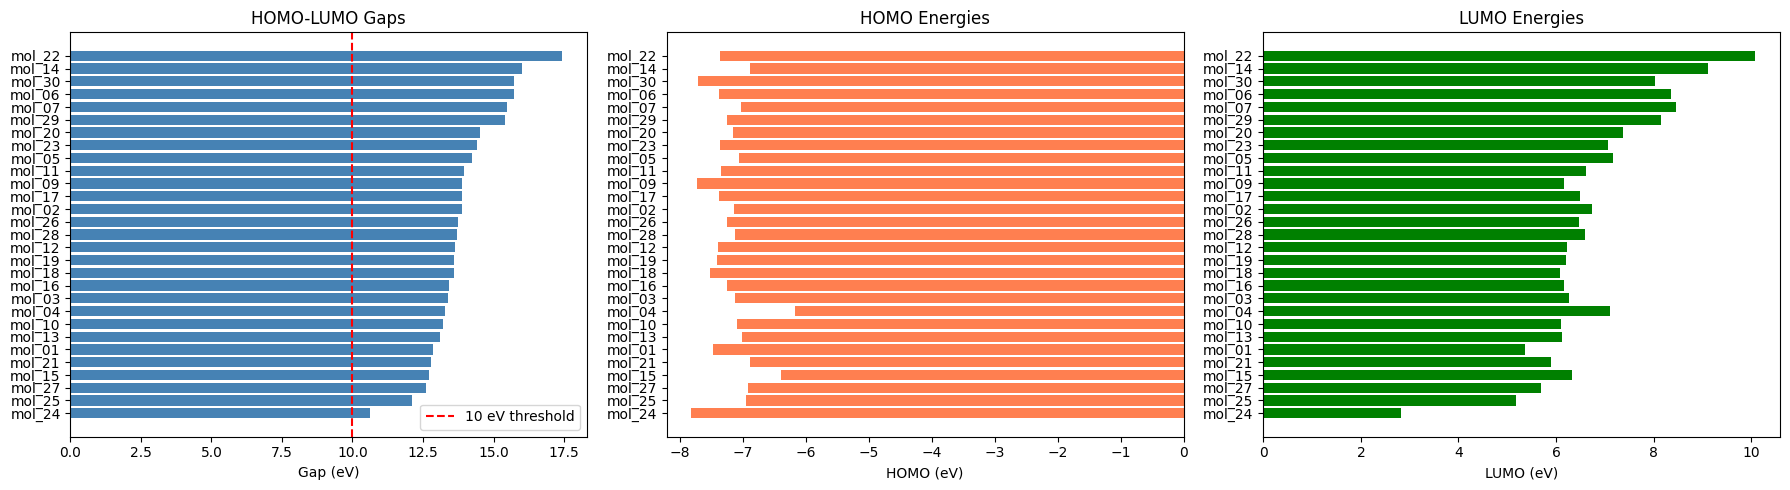

 Plot saved!


In [12]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values('gap_ev')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# HOMO-LUMO Gap
axes[0].barh(df_sorted['mol_name'], df_sorted['gap_ev'], color='steelblue')
axes[0].axvline(x=10, color='red', linestyle='--', label='10 eV threshold')
axes[0].set_xlabel('Gap (eV)')
axes[0].set_title('HOMO-LUMO Gaps')
axes[0].legend()

# HOMO energies
axes[1].barh(df_sorted['mol_name'], df_sorted['homo_ev'], color='coral')
axes[1].set_xlabel('HOMO (eV)')
axes[1].set_title('HOMO Energies')

# LUMO energies
axes[2].barh(df_sorted['mol_name'], df_sorted['lumo_ev'], color='green')
axes[2].set_xlabel('LUMO (eV)')
axes[2].set_title('LUMO Energies')

plt.tight_layout()
plt.savefig(f'{output_dir}/homo_lumo_plot.png', dpi=150)
plt.show()
print(" Plot saved!")

In [13]:
# Best candidates = lowest gap (most reactive)
# and HOMO closest to 0 (easiest to donate electrons)

df['reactivity_score'] = df['homo_ev'] + df['gap_ev']

top5 = df.nsmallest(5, 'gap_ev')
print(" Top 5 Most Reactive Molecules (smallest HOMO-LUMO gap):")
print(top5[['mol_name','homo_ev','lumo_ev','gap_ev']].to_string())

print("\n  Most Stable Molecules (largest gap — harder to react):")
bottom5 = df.nlargest(5, 'gap_ev')
print(bottom5[['mol_name','homo_ev','lumo_ev','gap_ev']].to_string())

 Top 5 Most Reactive Molecules (smallest HOMO-LUMO gap):
   mol_name   homo_ev   lumo_ev     gap_ev
22   mol_24 -7.818051  2.813159  10.631210
23   mol_25 -6.953629  5.168408  12.122037
25   mol_27 -6.917698  5.695207  12.612905
13   mol_15 -6.388450  6.324241  12.712690
19   mol_21 -6.883330  5.886865  12.770194

  Most Stable Molecules (largest gap — harder to react):
   mol_name   homo_ev    lumo_ev     gap_ev
20   mol_22 -7.361448  10.083420  17.444868
12   mol_14 -6.889195   9.110737  15.999932
28   mol_30 -7.708601   8.031691  15.740292
5    mol_06 -7.372791   8.359344  15.732135
6    mol_07 -7.034941   8.457567  15.492508


In [14]:
# Save one master file with everything
df_final = df[['mol_name','energy_hartree','homo_ev','lumo_ev','gap_ev']]
df_final.to_csv(f'{output_dir}/phase4_member1_final.csv', index=False)
print(" phase4_member1_final.csv saved to Drive!")
print(f" Location: {output_dir}/phase4_member1_final.csv")
print(f"\nTotal molecules: {len(df_final)}")

 phase4_member1_final.csv saved to Drive!
 Location: /content/drive/MyDrive/phase4_member1/outputs/qm/phase4_member1_final.csv

Total molecules: 29
